# linear-threshold-unit

A small, faithful reproduction of the paper that **invented the artificial neuron** — rebuilt in modern Python and **plotted** so you can *see* each idea. Run the cells top to bottom; each one adds a single piece.

> Warren S. McCulloch & Walter Pitts (1943). *A Logical Calculus of the Ideas Immanent in Nervous Activity.* The Bulletin of Mathematical Biophysics 5(4):115–133. [doi:10.1007/BF02478259](https://doi.org/10.1007/BF02478259)

**The big idea:** a neuron is *all-or-none* — it either fires or it doesn't. So “this neuron fired” is just a **true/false** statement, and a network of neurons becomes a circuit that computes **logic**. The unit they describe is a **linear threshold unit**: it adds up its inputs and fires once the total crosses a threshold.

### Words to know

- **all-or-none** — a neuron is either fully *firing* (`1`) or *silent* (`0`); nothing in between.
- **threshold** — how large the input total must be to make the neuron fire.
- **excitatory input** — an input that pushes the neuron *toward* firing (it gets counted).
- **inhibitory input** — an input that *vetoes* firing (one active inhibitor is enough to silence it).
- **linearly separable** — a problem you can solve by drawing one straight line between the “yes” and “no” cases. A linear threshold unit can only do these.

## 1. The neuron: count, then threshold

The least a neuron could do: **add up its inputs, and fire if the total reaches a threshold.** No weights, no learning — just counting and a cutoff.

In [1]:
def neuron(inputs, threshold):
    total = sum(inputs)                     # add up the inputs that are ON (the 1s)
    return 1 if total >= threshold else 0   # fire only if the total reaches the threshold

In [2]:
print("both inputs on:", neuron([1, 1], threshold=2))
print("one input on:  ", neuron([1, 0], threshold=2))

both inputs on: 1
one input on:   0


## 2. The threshold alone picks the gate

Here's the first surprise: **the threshold by itself turns this one neuron into different logic gates.**

- Threshold **2** → fires only when *both* inputs are on → **AND**.
- Threshold **1** → *either* input is enough → **OR**.

In [3]:
def AND(a, b):
    return neuron([a, b], threshold=2)   # fires only if BOTH are on (total reaches 2)

def OR(a, b):
    return neuron([a, b], threshold=1)   # fires if EITHER is on (total reaches 1)

bits = [(0, 0), (0, 1), (1, 0), (1, 1)]
for name, gate in [("AND", AND), ("OR", OR)]:
    print(name)
    for a, b in bits:
        print(f"  {a} {b} -> {gate(a, b)}")

AND
  0 0 -> 0
  0 1 -> 0
  1 0 -> 0
  1 1 -> 1
OR
  0 0 -> 0
  0 1 -> 1
  1 0 -> 1
  1 1 -> 1


Let's *see* it: the neuron's output as the number of active inputs grows. The jump from 0 to 1 is the **all-or-none threshold** — and AND simply jumps one step later than OR.

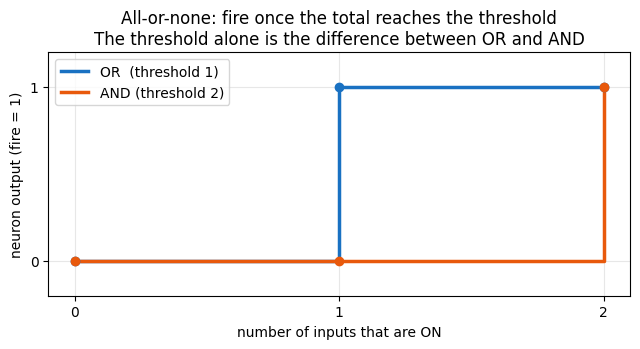

In [4]:
import matplotlib.pyplot as plt

totals  = [0, 1, 2]                                  # how many of the two inputs are ON
or_out  = [1 if t >= 1 else 0 for t in totals]       # OR  = threshold 1
and_out = [1 if t >= 2 else 0 for t in totals]       # AND = threshold 2

fig, ax = plt.subplots(figsize=(6.5, 3.6))
ax.step(totals, or_out,  where="post", lw=2.5, color="#1971c2", label="OR  (threshold 1)")
ax.step(totals, and_out, where="post", lw=2.5, color="#e8590c", label="AND (threshold 2)")
ax.scatter(totals, or_out,  color="#1971c2", zorder=3)
ax.scatter(totals, and_out, color="#e8590c", zorder=3)
ax.set_xticks(totals); ax.set_yticks([0, 1]); ax.set_ylim(-0.2, 1.2)
ax.set_xlabel("number of inputs that are ON"); ax.set_ylabel("neuron output (fire = 1)")
ax.set_title("All-or-none: fire once the total reaches the threshold\nThe threshold alone is the difference between OR and AND")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 3. We hit a wall: NOT

Now try to build **NOT** — "fire when the input is *off*." You can't: adding inputs only ever pushes a neuron *toward* firing, never away from it.

So the model adds a second kind of input — an **inhibitory** one. In 1943 it's *absolute*: **a single inhibitory signal vetoes firing entirely**, no matter the total. That's the one piece we add.

In [5]:
def neuron(inputs, threshold, inhibited=False):
    if inhibited:                           # one inhibitory signal shuts it down completely
        return 0
    total = sum(inputs)
    return 1 if total >= threshold else 0

Now **NOT** is a neuron that's *on by default* (threshold `0`, no excitatory inputs) which its input simply switches off.

In [6]:
def NOT(a):
    return neuron([], threshold=0, inhibited=bool(a))   # on by default; 'a' switches it off

print("NOT")
for a in (0, 1):
    print(f"  {a} -> {NOT(a)}")

NOT
  0 -> 1
  1 -> 0


## 4. Wire gates into a network → *any* logic (XOR)

A single linear threshold unit draws exactly **one straight line** through the inputs — so it can only solve **linearly separable** problems. **XOR** ("one or the other, but not both") isn't one of them. Here's *why*: each panel plots the four inputs, marked by output (filled = fires, hollow = silent). Try to fence the `1`s off from the `0`s with one line.

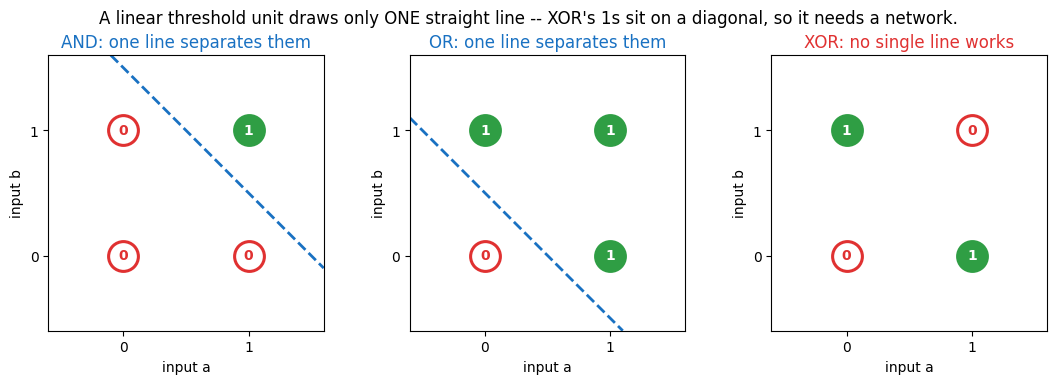

In [7]:
import matplotlib.pyplot as plt

def XOR(a, b):
    return AND(OR(a, b), NOT(AND(a, b)))   # a network of three gates we already built

# a straight line that cleanly separates the firing cases, where one exists
sep_lines = {"AND": ([-0.1, 1.6], [1.6, -0.1]),   # line a+b = 1.5  -> fences off the lone (1,1)
             "OR":  ([-0.6, 1.1], [1.1, -0.6])}    # line a+b = 0.5  -> fences off the lone (0,0)

fig, axes = plt.subplots(1, 3, figsize=(11, 3.7))
for ax, (name, gate) in zip(axes, [("AND", AND), ("OR", OR), ("XOR", XOR)]):
    for a in (0, 1):
        for b in (0, 1):
            out = gate(a, b)
            ax.scatter(a, b, s=460, zorder=3,
                       c=("#2f9e44" if out else "white"),
                       edgecolors=("#2f9e44" if out else "#e03131"), linewidths=2.2)
            ax.text(a, b, str(out), ha="center", va="center", zorder=4,
                    color=("white" if out else "#e03131"), fontweight="bold")
    if name in sep_lines:
        ax.plot(*sep_lines[name], "--", color="#1971c2", lw=2)
        ax.set_title(f"{name}: one line separates them", color="#1971c2")
    else:
        ax.set_title("XOR: no single line works", color="#e03131")
    ax.set_xlim(-0.6, 1.6); ax.set_ylim(-0.6, 1.6); ax.set_aspect("equal")
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xlabel("input a"); ax.set_ylabel("input b")

fig.suptitle("A linear threshold unit draws only ONE straight line -- XOR's 1s sit on a diagonal, so it needs a network.")
plt.tight_layout(); plt.show()

That diagonal is exactly what **"not linearly separable"** means. The fix is McCulloch & Pitts' real result: **a *network* of these units can compute anything.**

```
   a ─┬───────────────► OR(a,b) ───────────────┐
      │                                          ├─► AND ─► XOR
   b ─┴─► AND(a,b) ─► NOT(AND(a,b)) ─────────────┘

   XOR = AND( OR(a, b) , NOT(AND(a, b)) )
```

In [8]:
print("XOR")
for a, b in bits:
    print(f"  {a} {b} -> {XOR(a, b)}")

XOR
  0 0 -> 0
  0 1 -> 1
  1 0 -> 1
  1 1 -> 0


## 5. Loop it → memory

Everything so far flows forward. Now **feed a neuron's own output back into itself** — that loop is what lets it *remember*. Once a `set` input switches it on, it keeps re-firing (it **reverberates**) until a `reset` inhibits it. The authors call this firing “a memory — or an idea.”

In [9]:
def memory_step(set_now, reset_now, was_on):
    # the neuron sees the SET signal AND its own previous output (was_on).
    # that feedback -- its output looping back in -- is what lets it remember.
    return neuron([set_now, was_on], threshold=1, inhibited=bool(reset_now))

In [10]:
# (set, reset) at each tick of time:  set at t=1, reset at t=4
ticks = [(0, 0), (1, 0), (0, 0), (0, 0), (0, 1), (0, 0)]

states, state = [], 0
print("t   set reset   state")
for t, (set_now, reset_now) in enumerate(ticks):
    state = memory_step(set_now, reset_now, state)
    states.append(state)
    print(f"{t}    {set_now}    {reset_now}       {state}")

t   set reset   state
0    0    0       0
1    1    0       1
2    0    0       1
3    0    0       1
4    0    1       0
5    0    0       0


Plotted over time, you can watch the state turn on at **set**, **hold by itself** with no further input, then clear at **reset**:

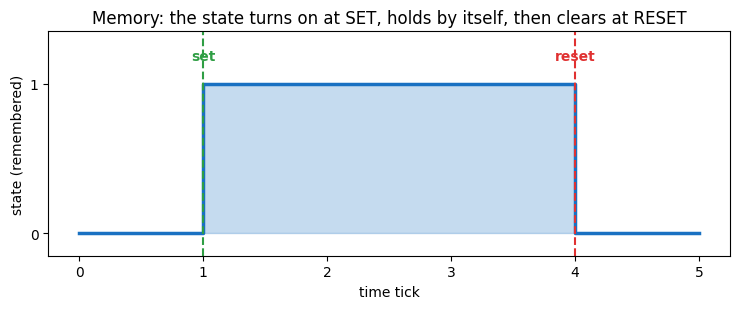

In [11]:
import matplotlib.pyplot as plt

T = list(range(len(ticks)))
fig, ax = plt.subplots(figsize=(7.5, 3.2))
ax.fill_between(T, states, step="post", alpha=0.25, color="#1971c2")
ax.step(T, states, where="post", lw=2.5, color="#1971c2")
for t, (set_now, reset_now) in zip(T, ticks):
    if set_now:
        ax.axvline(t, color="#2f9e44", ls="--"); ax.text(t, 1.16, "set", color="#2f9e44", ha="center", fontweight="bold")
    if reset_now:
        ax.axvline(t, color="#e03131", ls="--"); ax.text(t, 1.16, "reset", color="#e03131", ha="center", fontweight="bold")
ax.set_ylim(-0.15, 1.35); ax.set_yticks([0, 1]); ax.set_xticks(T)
ax.set_xlabel("time tick"); ax.set_ylabel("state (remembered)")
ax.set_title("Memory: the state turns on at SET, holds by itself, then clears at RESET")
plt.tight_layout(); plt.show()

## Self-check

A few assertions so the notebook proves itself — if any result disagreed with the paper, the cell would error.

In [12]:
assert [AND(a, b) for a, b in bits] == [0, 0, 0, 1]
assert [OR(a, b) for a, b in bits]  == [0, 1, 1, 1]
assert [NOT(a) for a in (0, 1)]     == [1, 0]
assert [XOR(a, b) for a, b in bits] == [0, 1, 1, 0]
assert states == [0, 1, 1, 1, 0, 0]
print("All checks pass -- one neuron, four ideas, true to 1943.")

All checks pass -- one neuron, four ideas, true to 1943.


## The whole neuron, in one place

We grew it across the notebook; here it is complete. That's the entire McCulloch–Pitts linear threshold unit:

```python
def neuron(inputs, threshold, inhibited=False):
    if inhibited:                           # absolute inhibition: one veto stops it
        return 0
    total = sum(inputs)                     # count the active excitatory inputs
    return 1 if total >= threshold else 0   # fire if the count meets the threshold
```

## Why it matters

Put it together and a network of these units is exactly a **finite-state machine** — logic plus memory. McCulloch & Pitts close with the famous result: a net *"furnished with a tape… can compute only such numbers as can a Turing machine."* In other words, **network + an external memory tape = a universal computer** — the bridge from *brains* to *computers*, written in 1943, before either modern neuroscience or the digital computer existed. It is the unit every artificial neuron since is built on.

---

*Educational reproduction by [Average Joes Lab](https://averagejoeslab.com). All credit for the ideas to McCulloch & Pitts (1943).*